# Retail Transaction Insights — Graded Mini Project (Part B)

Runs on the **full** `Retail_Transactions_Dataset.csv` (place it in the same folder as this
notebook before running). All six tasks from the brief are covered, with saved chart images
under `charts/`.

**Design notes / assumptions**
- The `Product` column is stored as a string that looks like a Python list
  (e.g. `['Ketchup', 'Shaving Cream']`); it is parsed back into a real list with
  `ast.literal_eval` so individual products can be counted.
- `Discount_Applied` (`TRUE`/`FALSE` text) is converted to a real boolean.
- `Promotion`'s literal text `"None"` is treated as its own clean category, `"No Promotion"`,
  rather than a missing value.
- `Date` is parsed with `format="mixed", dayfirst=True` so it tolerates either
  `DD-MM-YYYY HH:MM` or ISO-style timestamps; `Year`, `Month`, `MonthName`, `DayOfWeek` are
  extracted as separate columns.
- Exact duplicate rows and rows with an unparseable `Date` are dropped **before** the
  `Product_List` column is created, since a column of Python lists is unhashable and breaks
  `drop_duplicates()`.


In [1]:
import ast
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

DATA_PATH = "Retail_Transactions_Dataset.csv"
CHART_DIR = "charts"
os.makedirs(CHART_DIR, exist_ok=True)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)


## Task 1: Data Preparation

In [2]:
df = pd.read_csv(DATA_PATH)

# Parse dates. format="mixed" infers the format row-by-row so either
# day-first "21-01-2022 06:27" or ISO "2022-01-21 06:27:29" style parses correctly.
df["Date"] = pd.to_datetime(df["Date"], format="mixed", dayfirst=True, errors="coerce")

# Extract useful date parts
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["MonthName"] = df["Date"].dt.month_name()
df["DayOfWeek"] = df["Date"].dt.day_name()

# Convert Discount_Applied text to boolean
df["Discount_Applied"] = (
    df["Discount_Applied"].astype(str).str.strip().str.upper().map(
        {"TRUE": True, "FALSE": False}
    )
)

# Treat the literal "None" promotion as its own clean category
df["Promotion"] = df["Promotion"].fillna("No Promotion")
df["Promotion"] = df["Promotion"].replace("None", "No Promotion")

# Basic cleaning: drop exact duplicate rows, drop rows with no valid date
# (done BEFORE adding the Product_List column, since a column of Python lists
# is unhashable and breaks drop_duplicates)
before = len(df)
df = df.drop_duplicates()
df = df.dropna(subset=["Date"])
after = len(df)
if before != after:
    print(f"Cleaning: removed {before - after} duplicate/invalid-date rows.")

# Parse Product column from "['A', 'B']" string into a real list
def parse_products(val):
    try:
        return ast.literal_eval(val)
    except (ValueError, SyntaxError, TypeError):
        return []

df["Product_List"] = df["Product"].apply(parse_products)

# Make sure numeric columns are numeric
df["Total_Items"] = pd.to_numeric(df["Total_Items"], errors="coerce")
df["Total_Cost"] = pd.to_numeric(df["Total_Cost"], errors="coerce")

# Drop rows where the core numeric fields failed to parse at all
df = df.dropna(subset=["Total_Items", "Total_Cost"])

print(f"Final cleaned row count: {len(df):,}")
df.head()


Final cleaned row count: 1,000,000


,Transaction_ID,Date,Customer_Name,Product,Total_Items,Total_Cost,Payment_Method,City,Store_Type,Discount_Applied,Customer_Category,Season,Promotion,Year,Month,MonthName,DayOfWeek,Product_List
0,1000000000,2022-01-21 06:27:29,Stacey Price,"['Ketchup', 'Shaving Cream', 'Light Bulbs']",3,71.65,Mobile Payment,Los Angeles,Warehouse Club,True,Homemaker,Winter,No Promotion,2022,1,January,Friday,"[Ketchup, Shaving Cream, Light Bulbs]"
1,1000000001,2023-01-03 13:01:21,Michelle Carlson,"['Ice Cream', 'Milk', 'Olive Oil', 'Bread', 'P...",2,25.93,Cash,San Francisco,Specialty Store,True,Professional,Fall,BOGO (Buy One Get One),2023,1,January,Tuesday,"[Ice Cream, Milk, Olive Oil, Bread, Potatoes]"
2,1000000002,2024-03-21 15:37:04,Lisa Graves,['Spinach'],6,41.49,Credit Card,Houston,Department Store,True,Professional,Winter,No Promotion,2024,3,March,Thursday,[Spinach]
3,1000000003,2020-10-31 09:59:47,Mrs. Patricia May,"['Tissues', 'Mustard']",1,39.34,Mobile Payment,Chicago,Pharmacy,True,Homemaker,Spring,No Promotion,2020,10,October,Saturday,"[Tissues, Mustard]"
4,1000000004,2020-10-12 00:59:59,Susan Mitchell,['Dish Soap'],10,16.42,Debit Card,Houston,Specialty Store,False,Young Adult,Winter,Discount on Selected Items,2020,10,October,Monday,[Dish Soap]


## Task 2: Basic Exploration

In [3]:
total_transactions = len(df)
unique_customers = df["Customer_Name"].nunique()
print(f"Total transactions: {total_transactions:,}")
print(f"Unique customers: {unique_customers:,}")


Total transactions: 1,000,000
Unique customers: 329,738


In [4]:
# Top 5 most common products
all_products = df["Product_List"].explode()
top_products = all_products.value_counts().head(5)
print("Top 5 most common products:")
print(top_products.to_string())


Top 5 most common products:
Product_List
Toothpaste    73324
Ice Cream     37094
Soap          37076
Jam           36956
Orange        36928


In [5]:
# Cities ranked by number of transactions
top_cities = df["City"].value_counts()
print("Cities ranked by number of transactions (top 10):")
print(top_cities.head(10).to_string())


Cities ranked by number of transactions (top 10):
City
Boston           100566
Dallas           100559
Seattle          100167
Chicago          100059
Houston          100050
New York         100007
Los Angeles       99879
Miami             99839
San Francisco     99808
Atlanta           99066


## Task 3: Customer Behaviour Analysis

In [6]:
# Average spend by customer category
avg_spend_by_category = (
    df.groupby("Customer_Category")["Total_Cost"].mean().sort_values(ascending=False)
)
print("Average spend by customer category (highest first):")
print(avg_spend_by_category.round(2).to_string())


Average spend by customer category (highest first):
Customer_Category
Teenager          52.53
Professional      52.53
Student           52.49
Homemaker         52.46
Young Adult       52.45
Retiree           52.44
Middle-Aged       52.41
Senior Citizen    52.34


In [7]:
# Preferred payment method per customer category
preferred_payment = (
    df.groupby("Customer_Category")["Payment_Method"]
    .agg(lambda s: s.value_counts().idxmax())
)
print("Most-used payment method per customer category:")
print(preferred_payment.to_string())

payment_crosstab = pd.crosstab(df["Customer_Category"], df["Payment_Method"])
print("\nFull breakdown (counts):")
print(payment_crosstab.to_string())


Most-used payment method per customer category:
Customer_Category
Homemaker            Credit Card
Middle-Aged       Mobile Payment
Professional                Cash
Retiree              Credit Card
Senior Citizen              Cash
Student                     Cash
Teenager             Credit Card
Young Adult           Debit Card

Full breakdown (counts):
Payment_Method      Cash  Credit Card  Debit Card  Mobile Payment
Customer_Category                                                
Homemaker          31360        31413       31315           31330
Middle-Aged        31078        31049       31198           31311
Professional       31246        31201       31118           31086
Retiree            31269        31408       31051           31344
Senior Citizen     31442        31425       31420           31198
Student            31307        31058       31287           31190
Teenager           31203        31467       31322           31327
Young Adult        31325        30964       31363 

In [8]:
# Average items per transaction, per store type
avg_items_by_store = (
    df.groupby("Store_Type")["Total_Items"].mean().sort_values(ascending=False)
)
print("Average items per transaction, by store type:")
print(avg_items_by_store.round(2).to_string())


Average items per transaction, by store type:
Store_Type
Specialty Store      5.51
Convenience Store    5.51
Pharmacy             5.50
Department Store     5.50
Supermarket          5.49
Warehouse Club       5.48


## Task 4: Promotion & Discount Impact

In [9]:
# Average cost: discount applied vs not
avg_cost_by_discount = df.groupby("Discount_Applied")["Total_Cost"].mean()
print("Average transaction cost - Discount applied vs not:")
print(avg_cost_by_discount.round(2).to_string())


Average transaction cost - Discount applied vs not:
Discount_Applied
False    52.42
True     52.49


In [10]:
# Average items purchased per promotion type
avg_items_by_promo = (
    df.groupby("Promotion")["Total_Items"].mean().sort_values(ascending=False)
)
print("Average items purchased, by promotion type:")
print(avg_items_by_promo.round(2).to_string())


Average items purchased, by promotion type:
Promotion
Discount on Selected Items    5.50
BOGO (Buy One Get One)        5.49
No Promotion                  5.49


In [11]:
# "Most effective" promotion — looked at from two angles, since average
# transaction value alone can reward a promo that's rarely used.
promo_stats = df.groupby("Promotion").agg(
    avg_cost=("Total_Cost", "mean"),
    total_revenue=("Total_Cost", "sum"),
    transaction_count=("Total_Cost", "count"),
).round(2).sort_values("avg_cost", ascending=False)

print("Promotion performance (average cost, total revenue, and volume):")
print(promo_stats.to_string())

best_promo_by_avg = promo_stats["avg_cost"].idxmax()
best_promo_by_revenue = promo_stats["total_revenue"].idxmax()

print(f"\n-> Highest average transaction value: '{best_promo_by_avg}'")
print(f"-> Highest total revenue contribution: '{best_promo_by_revenue}'")


Promotion performance (average cost, total revenue, and volume):
                            avg_cost  total_revenue  transaction_count
Promotion                                                             
No Promotion                   52.57    17554038.81             333943
BOGO (Buy One Get One)         52.42    17438953.65             332687
Discount on Selected Items     52.38    17462227.94             333370

-> Highest average transaction value: 'No Promotion'
-> Highest total revenue contribution: 'No Promotion'


## Task 5: Seasonality Trends

In [12]:
# Total revenue by season
revenue_by_season = df.groupby("Season")["Total_Cost"].sum().sort_values(ascending=False)
print("Total revenue by season (highest first):")
print(revenue_by_season.round(2).to_string())

top_season = revenue_by_season.index[0]
print(f"\n-> Highest-revenue season: {top_season}")


Total revenue by season (highest first):
Season
Fall      13136913.71
Summer    13116675.79
Spring    13113238.75
Winter    13088392.15

-> Highest-revenue season: Fall


In [13]:
# Seasonal preference for store types (counts)
season_store_pref = pd.crosstab(df["Season"], df["Store_Type"])
print("Transaction counts by Season vs Store Type:")
print(season_store_pref.to_string())


Transaction counts by Season vs Store Type:
Store_Type  Convenience Store  Department Store  Pharmacy  Specialty Store  Supermarket  Warehouse Club
Season                                                                                                 
Fall                    41654             41593     41852            41606        41526           42017
Spring                  41798             41590     41825            41570        41845           41740
Summer                  41735             41623     41520            41362        41953           41428
Winter                  41562             41808     41718            41563        41612           41500


In [14]:
# Most popular product per season
exploded = df[["Season", "Product_List"]].explode("Product_List")
top_product_per_season = (
    exploded.groupby("Season")["Product_List"]
    .agg(lambda s: s.value_counts().idxmax() if len(s.dropna()) else None)
)
print("Most popular product per season:")
print(top_product_per_season.to_string())


Most popular product per season:
Season
Fall      Toothpaste
Spring    Toothpaste
Summer    Toothpaste
Winter    Toothpaste


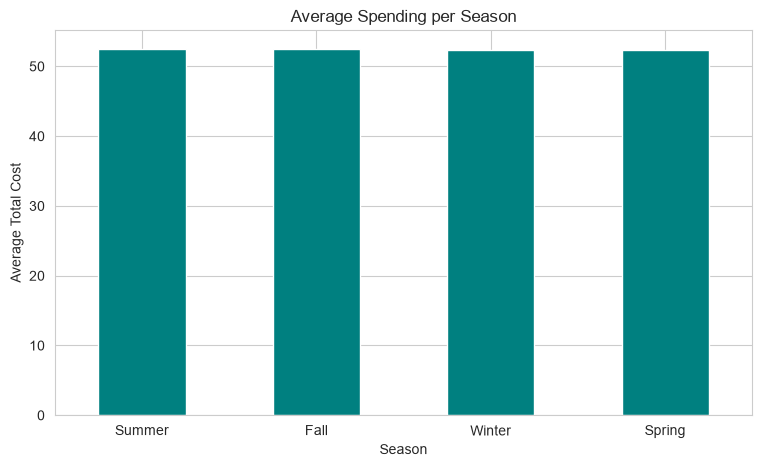

In [15]:
# Plot: average spending per season
avg_spend_by_season = df.groupby("Season")["Total_Cost"].mean().sort_values(ascending=False)

fig, ax = plt.subplots()
avg_spend_by_season.plot(kind="bar", color="teal", ax=ax)
ax.set_title("Average Spending per Season")
ax.set_xlabel("Season")
ax.set_ylabel("Average Total Cost")
plt.xticks(rotation=0)
fig.savefig(os.path.join(CHART_DIR, "avg_spending_per_season.png"), bbox_inches="tight", dpi=120)
plt.show()


## Task 6: Visualisation Dashboard

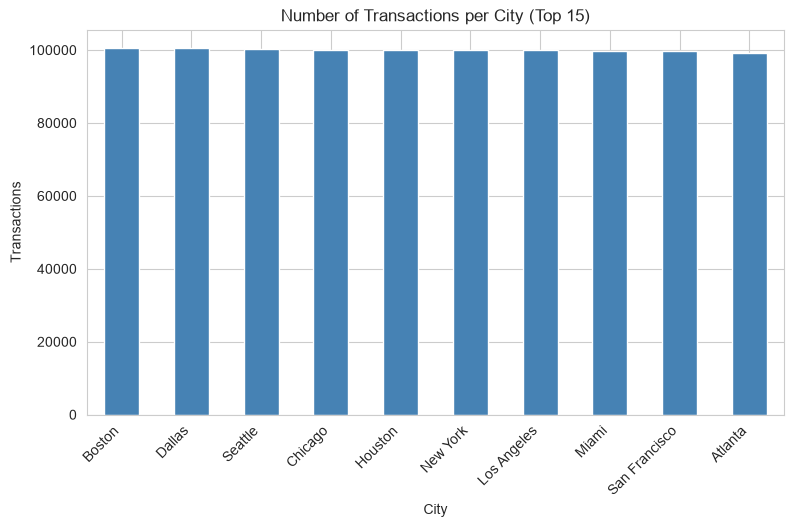

In [16]:
# 1. Bar plot: number of transactions per city (top 15 for readability on large datasets)
fig, ax = plt.subplots()
df["City"].value_counts().head(15).plot(kind="bar", color="steelblue", ax=ax)
ax.set_title("Number of Transactions per City (Top 15)")
ax.set_xlabel("City")
ax.set_ylabel("Transactions")
plt.xticks(rotation=45, ha="right")
fig.savefig(os.path.join(CHART_DIR, "transactions_per_city.png"), bbox_inches="tight", dpi=120)
plt.show()


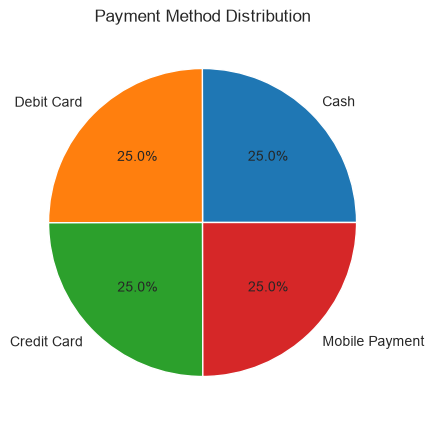

In [17]:
# 2. Pie chart: payment method distribution
fig, ax = plt.subplots()
df["Payment_Method"].value_counts().plot(kind="pie", autopct="%1.1f%%", ax=ax, ylabel="")
ax.set_title("Payment Method Distribution")
fig.savefig(os.path.join(CHART_DIR, "payment_method_distribution.png"), bbox_inches="tight", dpi=120)
plt.show()


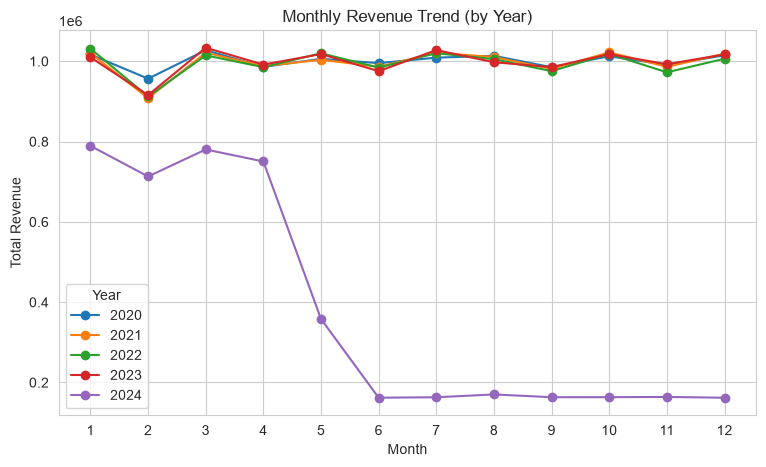

In [18]:
# 3. Line chart: monthly revenue trend (grouped by year)
monthly_revenue = df.groupby(["Year", "Month"])["Total_Cost"].sum().reset_index()

fig, ax = plt.subplots()
for year, grp in monthly_revenue.groupby("Year"):
    grp = grp.sort_values("Month")
    ax.plot(grp["Month"], grp["Total_Cost"], marker="o", label=str(int(year)))
ax.set_title("Monthly Revenue Trend (by Year)")
ax.set_xlabel("Month")
ax.set_ylabel("Total Revenue")
ax.set_xticks(range(1, 13))
ax.legend(title="Year")
fig.savefig(os.path.join(CHART_DIR, "monthly_revenue_trend.png"), bbox_inches="tight", dpi=120)
plt.show()


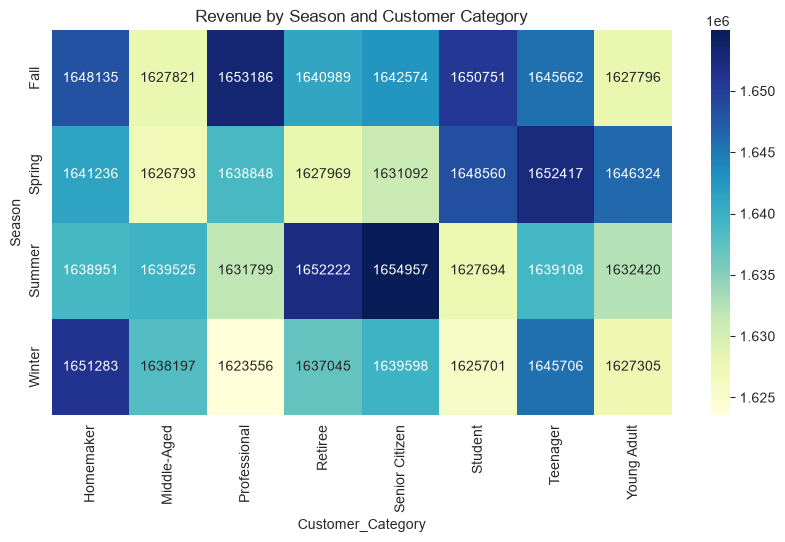

In [19]:
# 4. Heatmap: revenue by season and customer category
pivot = df.pivot_table(
    index="Season", columns="Customer_Category", values="Total_Cost", aggfunc="sum"
).fillna(0)

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="YlGnBu", ax=ax)
ax.set_title("Revenue by Season and Customer Category")
fig.savefig(os.path.join(CHART_DIR, "revenue_season_vs_category_heatmap.png"), bbox_inches="tight", dpi=120)
plt.show()


## Summary of Key Insights & Recommended Actions

In [20]:
top_city = top_cities.index[0]
top_product = top_products.index[0]
top_spender_category = avg_spend_by_category.index[0]
d_true = avg_cost_by_discount.get(True, float("nan"))
d_false = avg_cost_by_discount.get(False, float("nan"))
top_payment_method = df["Payment_Method"].value_counts().index[0]

print("KEY INSIGHTS")
print("-" * 60)
print(f"- Dataset covers {total_transactions:,} transactions from {unique_customers:,} unique customers.")
print(f"- '{top_product}' was the most frequently purchased product overall.")
print(f"- '{top_city}' recorded the highest number of transactions.")
print(f"- '{top_spender_category}' customers spend the most on average per transaction "
      f"(${avg_spend_by_category.iloc[0]:.2f}).")
print(f"- Discounted transactions averaged ${d_true:.2f} vs ${d_false:.2f} for non-discounted ones.")
print(f"- '{best_promo_by_avg}' has the highest average transaction value; "
      f"'{best_promo_by_revenue}' contributes the most total revenue overall — "
      f"these can differ because average value doesn't account for how often a promo is used.")
print(f"- '{top_season}' is the strongest-revenue season overall.")
print(f"- '{top_payment_method}' is the most commonly used payment method store-wide.")

print("\nRECOMMENDED ACTIONS")
print("-" * 60)
print(f"- Prioritise inventory and staffing for '{top_product}' and other top-5 products, "
      f"especially in '{top_city}', the highest-volume location.")
print(f"- Target '{top_spender_category}' customers with loyalty or upsell offers, since they "
      f"already spend the most per visit.")
print(f"- Re-evaluate promotions by total revenue, not just average order value — a promo with a "
      f"high average but low usage ('{best_promo_by_avg}') may be worth scaling up if profitable, "
      f"while '{best_promo_by_revenue}' is already the bigger overall revenue driver.")
print(f"- Plan inventory and marketing pushes ahead of '{top_season}', the strongest revenue season, "
      f"and investigate why other seasons under-perform.")
print(f"- Ensure checkout/payment infrastructure is optimised for '{top_payment_method}', "
      f"the dominant payment method.")


KEY INSIGHTS
------------------------------------------------------------
- Dataset covers 1,000,000 transactions from 329,738 unique customers.
- 'Toothpaste' was the most frequently purchased product overall.
- 'Boston' recorded the highest number of transactions.
- 'Teenager' customers spend the most on average per transaction ($52.53).
- Discounted transactions averaged $52.49 vs $52.42 for non-discounted ones.
- 'No Promotion' has the highest average transaction value; 'No Promotion' contributes the most total revenue overall — these can differ because average value doesn't account for how often a promo is used.
- 'Fall' is the strongest-revenue season overall.
- 'Cash' is the most commonly used payment method store-wide.

RECOMMENDED ACTIONS
------------------------------------------------------------
- Prioritise inventory and staffing for 'Toothpaste' and other top-5 products, especially in 'Boston', the highest-volume location.
- Target 'Teenager' customers with loyalty or ups